<a href="https://colab.research.google.com/github/Alexandre77777/neural_networks/blob/main/3.%20%D0%A1%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5%20%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5%20%D1%81%D0%B5%D1%82%D0%B8%20(CNN).%20%D0%9A%D0%BE%D0%BB%D0%B1%D1%8D%D0%BA%D0%B8.%20%D0%93%D1%80%D0%B0%D1%84%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B9%20%D0%B8%D0%BD%D1%82%D0%B5%D1%80%D1%84%D0%B5%D0%B9%D1%81/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%962_%D0%98%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%B8%D1%85_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%B8_%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №2. Использование глубоких нейронных сетей для решения задач регрессии и классификации



**Ссылка на код с пары:**
https://colab.research.google.com/drive/18EM8mrpURStkmbxWjZybWbWh23Si5b4A?usp=sharing


## Задание №1. Обучение модели ИНС для решения задачи регрессии



Постройте глубокую нейронную сеть для предсказания цен на недвижимость в городе Бостон, используя датасет датасет boston_housing_price

[Описание датасета](https://www.hackersrealm.net/post/boston-house-price-prediction-analysis-using-python)

#### 1.1. Загружаем исходные данные:

In [25]:
import gc
import os
import pickle

import gradio as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
import tensorflow as tf
from keras.optimizers import SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import mixed_precision
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.python.client import device_lib

gpus = tf.config.list_physical_devices("GPU")
print("Num GPUs Available: ", len(gpus))
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
mixed_precision.set_global_policy("mixed_float16")

RTX_5060_TI = "/device:GPU:0"
RTX_3060 = "/device:GPU:1"

print(gpus)
device_lib.list_local_devices()

Num GPUs Available:  2
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


I0000 00:00:1772530580.633657  803735 gpu_device.cc:2019] Created device /device:GPU:0 with 13893 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:07:00.0, compute capability: 12.0
I0000 00:00:1772530580.635943  803735 gpu_device.cc:2019] Created device /device:GPU:1 with 10264 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:04:00.0, compute capability: 8.6


[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 1278817832800510821
 xla_global_id: -1,
 name: "/device:GPU:0"
 device_type: "GPU"
 memory_limit: 14568783872
 locality {
   bus_id: 1
   links {
   }
 }
 incarnation: 18446012763951378790
 physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:07:00.0, compute capability: 12.0"
 xla_global_id: 416903419,
 name: "/device:GPU:1"
 device_type: "GPU"
 memory_limit: 10763501568
 locality {
   bus_id: 1
   links {
   }
 }
 incarnation: 6107171726901358396
 physical_device_desc: "device: 1, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:04:00.0, compute capability: 8.6"
 xla_global_id: 2144165316]

In [2]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [3]:
data = pd.DataFrame(data)
data.tail()

,0,1,2,3,4,5,6,7,8,9,10,11,12
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48
505,0.04741,0.0,11.93,0.0,0.573,6.030,80.8,2.5050,1.0,273.0,21.0,396.90,7.88


#### 1.1.2 Подготовка данных

In [4]:
cols = [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12]
scaler = MinMaxScaler()
data[cols] = scaler.fit_transform(data[cols])
data.tail()

,0,1,2,3,4,5,6,7,8,9,10,11,12
501,0.000633,0.0,0.420455,0.0,0.386831,0.580954,0.681771,0.122671,0.0,0.164122,0.893617,0.987619,0.219095
502,0.000438,0.0,0.420455,0.0,0.386831,0.490324,0.760041,0.105293,0.0,0.164122,0.893617,1.000000,0.202815
503,0.000612,0.0,0.420455,0.0,0.386831,0.654340,0.907312,0.094381,0.0,0.164122,0.893617,1.000000,0.107892
504,0.001161,0.0,0.420455,0.0,0.386831,0.619467,0.889804,0.114514,0.0,0.164122,0.893617,0.991301,0.131071
505,0.000462,0.0,0.420455,0.0,0.386831,0.473079,0.802266,0.125072,0.0,0.164122,0.893617,1.000000,0.169702


##### 1.1.2.1 Сохранение scaler для дальнейшего использования

In [5]:
BOSTON_SCALER_PATH = "./boston_scaler.pickle"
with open(BOSTON_SCALER_PATH, "wb") as f:
    pickle.dump(scaler, f)

#### 1.1.3 Подсчет пропусков

In [6]:
data.isna().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
dtype: int64

#### 1.2. Проектируем архитектуру для этой задачи

In [16]:
model = Sequential(
    [
        Input((12,)),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
tf.keras.backend.clear_session()
del model
gc.collect()

0

#### 1.3. Компилируем модель ИНС

Подберите нужную функцию потерь и метрику.

In [17]:
model.compile(optimizer=SGD(learning_rate=0.001), loss="mse", metrics=["mae"])

#### 1.4. Обучаем модель ИНС

In [18]:
x, y = data.loc[:, :11], data[12]
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2)

x_train.shape, x_val.shape, y_train.shape, y_val.shape

((404, 12), (102, 12), (404,), (102,))

In [19]:
%%time
history = model.fit(
    x_train,
    y_train,
    batch_size=8,
    validation_data=(x_val, y_val),
    epochs=30,
    verbose=1,
)

Epoch 1/30


2026-03-03 12:25:48.439244: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 12:25:48.439263: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 12:25:48.439269: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 12:25:48.439275: W external/loca

 1/51 ━━━━━━━━━━━━━━━━━━━━ 2:57 4s/step - loss: 0.1896 - mae: 0.4160

2026-03-03 12:25:51.837036: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 12:25:51.837052: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 12:25:51.837059: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 12:25:51.837064: W external/loca

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.1515 - mae: 0.3503

2026-03-03 12:25:54.804169: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 12:25:54.804186: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 12:25:55.481027: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_17', 152 bytes spill stores, 152 bytes spill loads

2026-03-03 12:25:55.562446: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.1433 - mae: 0.3351 - val_loss: 0.0857 - val_mae: 0.2532
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0958 - mae: 0.2601 - val_loss: 0.0553 - val_mae: 0.1880
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0668 - mae: 0.2036 - val_loss: 0.0378 - val_mae: 0.1430
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0492 - mae: 0.1648 - val_loss: 0.0278 - val_mae: 0.1162
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0385 - mae: 0.1402 - val_loss: 0.0224 - val_mae: 0.1047
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0321 - mae: 0.1259 - val_loss: 0.0195 - val_mae: 0.1001
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0283 - mae: 0.1183 - val_loss: 0.0180 - val_mae: 0.0982
Epoch 8/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0259 - mae: 0.1138 - val_loss: 0.0174 - val_mae: 0.0976
Epoch 9/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0244 - mae: 0.1115 - v

#### 1.6. Делаем предсказания на тестовых данных

In [20]:
preds = model.predict(x_val)

2026-03-03 12:26:05.138925: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 12:26:05.138943: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 12:26:05.774934: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9', 136 bytes spill stores, 136 bytes spill loads

2026-03-03 12:26:05.847878: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step


#### 1.7. Вычисляем метрику качества на тестовых данных

In [21]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(preds, y_val)

0.10055802382578123

#### 1.8. Сохраняем модель

In [24]:
model.save("boston.keras")

#### 1.8. Строим график обучения

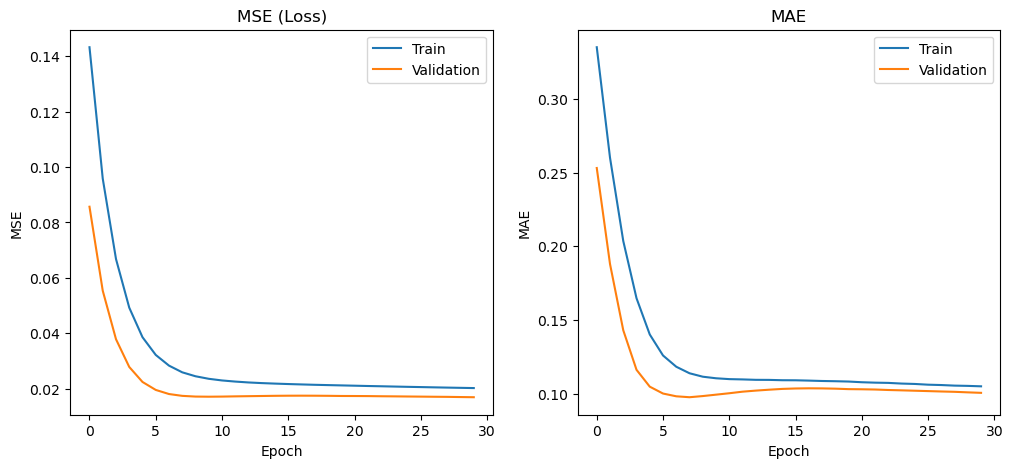

In [23]:
plt.figure(figsize=(12, 5))

# График MSE (loss)
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("MSE (Loss)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

# График MAE
plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train")
plt.plot(history.history["val_mae"], label="Validation")
plt.title("MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.show()

#### 1.9. Построение графического интерфейса в Gradio Проверка обученной модели пользовательскими данными

In [55]:
RAW_BOSTON = np.hstack(
    [
        pd.read_csv(data_url, sep="\s+", skiprows=22, header=None).values[::2, :],
        raw_df.values[1::2, :2],
    ]
)

In [148]:
FEATURES = [
    ("CRIM", "per capita crime rate by town"),
    ("ZN", "proportion of residential land zoned for lots > 25,000 sq.ft."),
    ("INDUS", "proportion of non-retail business acres per town"),
    ("CHAS", ""),
    ("NOX", "nitric oxides concentration (parts per 10 million)"),
    ("RM", "average number of rooms per dwelling"),
    ("AGE", "proportion of owner-occupied units built prior to 1940"),
    ("DIS", "weighted distances to 5 Boston employment centres"),
    ("RAD", "index of accessibility to radial highways"),
    ("TAX", "full-value property-tax rate per $10,000"),
    ("PTRATIO", "pupil-teacher ratio by town"),
    ("B", "1000(Bk - 0.63)^2 where Bk is proportion of Black people by town"),
    ("LSTAT", "% lower status of the population"),
]


def generate_ranges(X, features):
    ranges = {}

    for i, feat in enumerate(features):
        name = feat[0]
        if name == "CHAS":
            continue

        col = X[:, i]

        min_val = float(np.min(col))
        max_val = float(np.max(col))
        median_val = float(np.median(col))

        span = max_val - min_val
        if span > 100:
            step = 1.0
        elif span > 10:
            step = 0.1
        else:
            step = 0.01

        ranges[name] = (
            round(min_val, 4),
            round(max_val, 4),
            round(median_val, 4),
            step,
        )

    return ranges


RANGES = generate_ranges(
    RAW_BOSTON,
    FEATURES,
)


def preprocess(x_row):
    x = x_row.astype(np.float32).reshape(1, -1)
    sc = None
    with open(BOSTON_SCALER_PATH, "rb") as input_file:
        sc = pickle.load(input_file)
    if sc is not None:
        x = sc.transform(x)
    return x


def predict(*vals):
    m = load_model("boston.keras")

    x_row = np.array(vals, dtype=np.float32)
    x = preprocess(x_row)

    y = m.predict(x, verbose=0)
    return f"${y[0][0]*1000}"


with gr.Blocks(title="Boston Housing Price Predictor") as demo1:
    with gr.Row():
        with gr.Column(scale=2):
            sliders = []
            for key, desc in FEATURES:
                if key == "CHAS":
                    continue
                s = gr.Slider(
                    minimum=RANGES[key][0],
                    maximum=RANGES[key][1],
                    value=RANGES[key][2],
                    step=RANGES[key][3],
                    label=f"{key}",
                    info=desc,
                    interactive=True,
                )
                sliders.append(s)

        with gr.Column(scale=1):
            gr.Markdown("## Результат")
            out_main = gr.Textbox(label="Предсказание", interactive=False)

    for s in sliders:
        s.change(
            fn=predict,
            inputs=sliders,
            outputs=[out_main],
            queue=False,
        )
    demo1.load(fn=predict, inputs=sliders, outputs=[out_main], queue=False)

#### 2. Проверка обученной модели пользовательскими данными

In [153]:
try:
    demo1.launch(server_name="0.0.0.0", server_port=7000)
except OSError:
    gr.close_all()

* Running on local URL:  http://0.0.0.0:7000
* To create a public link, set `share=True` in `launch()`.


## Задание №2.Обучение модели ИНС для решения задачи классификации

Для обучения и валидации был создан композитный датасет на основе двух существующих:
https://www.kaggle.com/datasets/slothkong/10-monkey-species/data (~1400 изображений обезъян)
https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset (~25000 изображений кошек и собак в сумме)

Результирующий датасет представляет собой набор из трех классов (Кошки, Собаки, Обезьяны). В каждом из которых 1300 изображений.

### 1. Устанавливаем зависимости:

In [65]:
import json
import os
import pickle
import random
import shutil

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from imutils.paths import list_images
from keras.layers import Dense, Input
from keras.models import Model, Sequential
from keras.optimizers import SGD, Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.utils import to_categorical

### 2. Формируем композитный набор данных:

#### 2.1 Склеиваем наборы данных

In [20]:
def filepath_list_from(src_dir_paths):
    all_paths = []
    for path in src_dir_paths:
        all_paths.extend(list(list_images(path)))
    return all_paths


def random_rename(paths):
    new_paths = []
    for i, old_path in enumerate(paths):
        root = os.path.dirname(old_path)
        extension = os.path.splitext(old_path)[1]
        new_path = os.path.join(root, f"{i}{extension}")
        os.rename(old_path, new_path)
        new_paths.append(new_path)
    return new_paths


def mv_into(src_paths, dest_dir_path, overwrite=True):
    os.makedirs(dest_dir_path, exist_ok=True)

    for file_path in src_paths:
        filename = os.path.basename(file_path)
        destination = os.path.join(dest_dir_path, filename)

        # Если файл уже существует
        if os.path.exists(destination):
            if overwrite:
                os.remove(destination)
            else:
                name, ext = os.path.splitext(filename)
                counter = 1
                while os.path.exists(destination):
                    new_name = f"{name}_{counter}{ext}"
                    destination = os.path.join(target_dir, new_name)
                    counter += 1

        shutil.move(file_path, destination)
    return list(list_images(dest_dir_path))


monkey_paths = ["./datasets/monkey_dataset"]

print("Начало обработки...")

monkey_images = mv_into(random_rename(filepath_list_from(monkey_paths)), "./Monkey")

print("Готово!")

Начало обработки...
Готово!


#### 2.2 Получаем список файлов

In [25]:
cat_images = filepath_list_from(["./datasets/dog_cat_dataset/PetImages/Cat"])
dog_images = filepath_list_from(["./datasets/dog_cat_dataset/PetImages/Dog"])
monkey_images[:3], cat_images[:3], dog_images[:3]

(['./Monkey/45.jpg', './Monkey/1350.jpg', './Monkey/1351.jpg'],
 ['./datasets/dog_cat_dataset/PetImages/Cat/0.jpg',
  './datasets/dog_cat_dataset/PetImages/Cat/1.jpg',
  './datasets/dog_cat_dataset/PetImages/Cat/10.jpg'],
 ['./datasets/dog_cat_dataset/PetImages/Dog/0.jpg',
  './datasets/dog_cat_dataset/PetImages/Dog/1.jpg',
  './datasets/dog_cat_dataset/PetImages/Dog/10.jpg'])

#### 2.3 Указываем новые пути до классов

In [63]:
new_dataset_root = "./Animals"

new_dataset_monkeys_dir = f"{new_dataset_root}/Monkeys"
new_dataset_cats_dir = f"{new_dataset_root}/Cats"
new_dataset_dogs_dir = f"{new_dataset_root}/Dogs"

In [ ]:
def crop_class_into(class_images_paths, dest_dir, class_cardinality=1300):
    return random_rename(mv_into(class_images_paths[:class_cardinality], dest_dir))


print("Начало кроппинга датасетов...")

new_dataset_monkeys = crop_class_into(monkey_images, new_dataset_monkeys_dir)
new_dataset_cats = crop_class_into(cat_images, new_dataset_cats_dir)
new_dataset_dogs = crop_class_into(dog_images, new_dataset_dogs_dir)

print("Кроппинг датасетов завершен.")

In [28]:
[len(l) for l in (new_dataset_monkeys, new_dataset_cats, new_dataset_dogs)]

[1300, 1300, 1300]

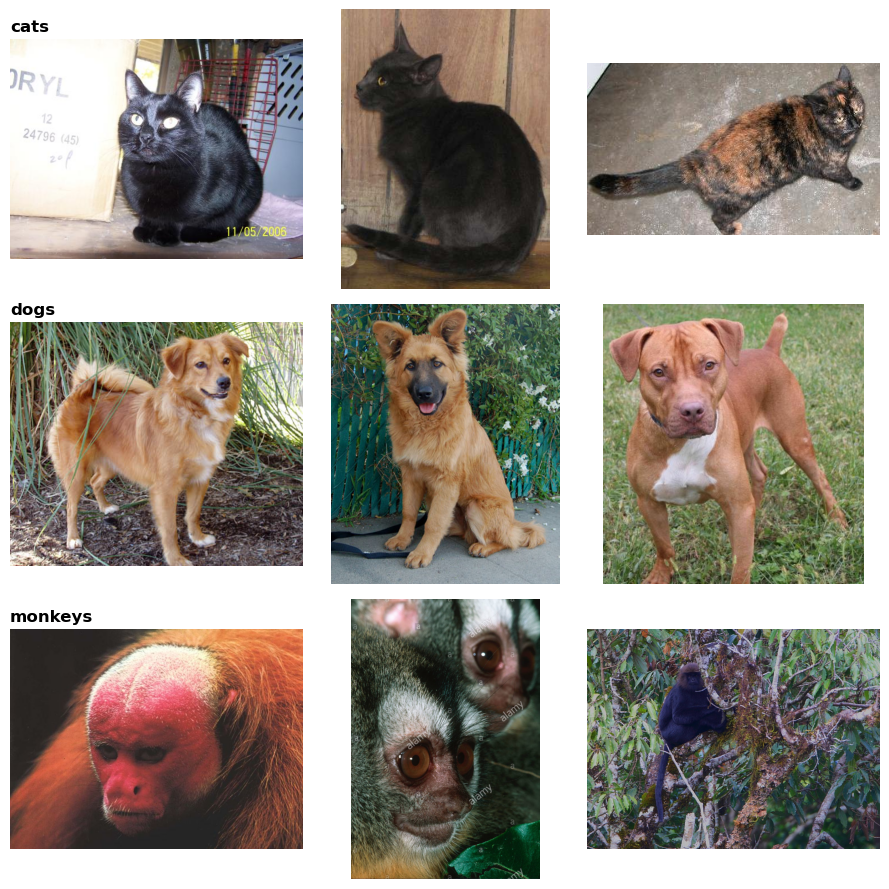

In [5]:
from PIL import Image


def show_grid_3x3(class_to_paths):
    """
    class_to_paths: dict
        {
            "class_name": [path1, path2, path3],
            ...
        }
    Отображает 3 класса по 3 изображения (сетка 3x3)
    """

    if len(class_to_paths) != 3:
        raise ValueError("Нужно передать ровно 3 класса для сетки 3x3")

    fig, axes = plt.subplots(3, 3, figsize=(9, 9))

    for row, (class_name, paths) in enumerate(class_to_paths.items()):
        if len(paths) != 3:
            raise ValueError(f"У класса {class_name} должно быть ровно 3 изображения")

        for col in range(3):
            ax = axes[row, col]
            img = Image.open(paths[col]).convert("RGB")
            ax.imshow(img)
            ax.axis("off")

            if col == 0:
                ax.set_title(class_name, loc="left", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()


show_grid_3x3(
    {
        "cats": list(list_images(new_dataset_cats_dir))[:3],
        "dogs": list(list_images(new_dataset_dogs_dir))[:3],
        "monkeys": list(list_images(new_dataset_monkeys_dir))[:3],
    }
)

### 4. Загружаем набор данных и формируем общую выборку:

In [133]:
imgs, labels = [], []
img_paths = list(list_images(new_dataset_root))
random.shuffle(img_paths)
img_width = 300
img_height = 300


def preprocess_image(image, new_width, new_height):
    return (
        cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_AREA)
        .flatten()
        .astype("float32")
        / 255
    )


for imgPath in img_paths:
    try:
        image = cv2.imread(imgPath)
        image = preprocess_image(image, img_width, img_height)
    except Exception as e:
        print(f"Битая картинка {imgPath} с исключением {e}")
        continue
    imgs.append(image)
    labels.append(imgPath.split(os.path.sep)[-2])

Битая картинка ./Animals/Cats/449.jpg с исключением OpenCV(4.13.0) /home/conda/feedstock_root/build_artifacts/libopencv_1770923948197/work/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'



In [67]:
unique_labels = np.unique(labels, return_inverse=True)
labels_str = unique_labels[0]
labels_int = unique_labels[1]

label_map = {lbl: idx for idx, lbl in enumerate(labels_str)}
label_map

{np.str_('Cats'): 0, np.str_('Dogs'): 1, np.str_('Monkeys'): 2}

#### 4.1. Нормализуем данные:

Масштабируем интенсивности пикселей в диапазон [0, 1], а также преобразуем данные в массивы NumPy для повышения производительности


In [68]:
img_data = np.array(imgs, dtype="float32") / 255.0

#### 4.2. Формируем обучающую и валидационную выборки:

Разделяем данные на обучающую и валидационную выборки, используя 75% данных для обучения и оставшиеся 25% для валидации

In [69]:
unique_labels

(array(['Cats', 'Dogs', 'Monkeys'], dtype='<U7'),
 array([0, 2, 1, ..., 0, 2, 1]))

In [70]:
labels_int

array([0, 2, 1, ..., 0, 2, 1])

In [71]:
trainX, testX, trainY_int, testY_int = train_test_split(
    img_data, labels_int, test_size=0.2
)
trainY = to_categorical(trainY_int, num_classes=len(labels_str)).astype("float32")
testY = to_categorical(testY_int, num_classes=len(labels_str)).astype("float32")
trainY_int, testY_int = trainY_int.astype("int32"), testY_int.astype("int32")
trainX, testX, trainY, testY

(array([[0.62352943, 0.5686275 , 0.6392157 , ..., 0.10196079, 0.1254902 ,
         0.15294118],
        [0.27058825, 0.39607844, 0.50980395, ..., 0.3764706 , 0.54509807,
         0.7176471 ],
        [0.20392157, 0.3372549 , 0.30980393, ..., 0.3529412 , 0.5882353 ,
         0.5568628 ],
        ...,
        [0.5019608 , 0.49803922, 0.5764706 , ..., 0.5764706 , 0.5294118 ,
         0.6156863 ],
        [0.01960784, 0.01960784, 0.01960784, ..., 0.08235294, 0.2       ,
         0.29803923],
        [0.61960787, 0.654902  , 0.69411767, ..., 0.2627451 , 0.40784314,
         0.57254905]], dtype=float32),
 array([[0.25882354, 0.3137255 , 0.92941177, ..., 0.6431373 , 0.6431373 ,
         0.61960787],
        [0.04313726, 0.14901961, 0.29411766, ..., 0.45882353, 0.44313726,
         0.46666667],
        [0.5058824 , 0.5176471 , 0.6666667 , ..., 0.69803923, 0.627451  ,
         0.7411765 ],
        ...,
        [0.5019608 , 0.5647059 , 0.52156866, ..., 0.18431373, 0.18039216,
         0.14117648

### 5. Создание модели:

#### 5.1. Определим архитектуру модели с помощью Keras:

In [72]:
# layer_config = [
#     (RTX_5060_TI, Dense(128, activation="relu")),
#     (RTX_3060, Dense(64, activation="relu")),
#     (RTX_3060, Dense(32, activation="relu")),
#     (RTX_3060, Dense(len(labels_str), activation="softmax")),
# ]


# def build_split_model(input_dim, layer_config):
#     inp = Input(shape=(input_dim,))
#     x = inp

#     for device, layer in layer_config:
#         with tf.device(device):
#             x = layer(x)

#     return Model(inp, x)


# model_img = build_split_model(img_width * img_height * 3, layer_config)
model_img = Sequential(
    [
        Input((img_width * img_height * 3,)),
        Dense(800, activation="relu"),
        Dense(512, activation="relu"),
        Dense(256, activation="relu"),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(len(labels_str), activation="softmax"),
    ]
)

model_img.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 800)            │   216,000,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       410,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,586,051 (826.21 MB)

 Trainable params: 216,586,051 (826.21 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
tf.keras.backend.clear_session()
del model_img
gc.collect()

0

#### 5.2. Установим значение параметров скорости обучения и общего числа эпох


In [73]:
INIT_LR = 0.0001
EPOCHS = 100
BATCH_SIZE = len(trainX)

#### 5.3. Компилируем модель:

In [74]:
model_img.compile(
    loss="sparse_categorical_crossentropy",
    # optimizer=SGD(learning_rate=INIT_LR, momentum=0.9, nesterov=True),
    optimizer=Adam(learning_rate=INIT_LR),
    metrics=["accuracy"],
    jit_compile=True,
)

### 6. Обучение модели искусственной нейронной сети:

In [75]:
%%time
AUTOTUNE = tf.data.AUTOTUNE
train_ds = (
    tf.data.Dataset.from_tensor_slices((trainX, trainY_int))
    .shuffle(len(trainX))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((testX, testY_int))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
H = model_img.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    # batch_size=BATCH_SIZE,
    callbacks=[  # без них сильно быстрее
        # tf.keras.callbacks.ReduceLROnPlateau(
        #     monitor="val_loss", factor=0.5, patience=100, min_lr=1e-6, verbose=1
        # ),
        # tf.keras.callbacks.EarlyStopping(
        #     monitor="val_loss", patience=200, restore_best_weights=True, verbose=1
        # ), # сильно замедляет
        # tf.keras.callbacks.ModelCheckpoint(
        #     "best.keras", monitor="val_loss", save_best_only=True, verbose=1
        # ), # сильно замедляет
        # tf.keras.callbacks.TensorBoard(
        #     log_dir=f"logs/fit/{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}",
        #     histogram_freq=1,
        # ),
    ],
)

Epoch 1/100


2026-03-03 15:03:05.759924: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 15:03:05.759942: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 15:03:06.365944: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_90', 8 bytes spill stores, 8 bytes spill loads

2026-03-03 15:03:06.532140: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Regis

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.3639 - loss: 1.1052

2026-03-03 15:03:15.303694: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 15:03:15.303712: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 15:03:15.978070: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_70', 8 bytes spill stores, 8 bytes spill loads

2026-03-03 15:03:16.164640: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Regis

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.3639 - loss: 1.1052 - val_accuracy: 0.3806 - val_loss: 2.4274
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3639 - loss: 2.4915 - val_accuracy: 0.3806 - val_loss: 2.4274
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3639 - loss: 2.4915 - val_accuracy: 0.3806 - val_loss: 2.4274
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3639 - loss: 2.4915 - val_accuracy: 0.3806 - val_loss: 2.4274
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3639 - loss: 2.4915 - val_accuracy: 0.3806 - val_loss: 2.4274
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3639 - loss: 2.4915 - val_accuracy: 0.3575 - val_loss: 2.6834
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3700 - loss: 2.6684 - val_accuracy: 0.3806 - val_loss: 2.1095
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3639 - loss: 2.1639 - val_accuracy: 0.2619 - val_loss: 1.4702
Epoch 9/100
1/1 ━━

#### 6.1. Загружаем лучшую модель:

In [76]:
# model.load_weights("best_weights.keras")
# best_model = tf.keras.models.load_model("best.keras")
best_model = model_img

### 7. Оценка точности:

#### 7.1. Выведем отчет классификации

In [77]:
preds = best_model.predict(testX)

# В classification_report передаём target_names=unique_labels
print(
    classification_report(
        testY.argmax(axis=1), preds.argmax(axis=1), target_names=labels_str
    )
)

2026-03-03 15:36:49.512335: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 15:36:49.512356: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 15:36:49.512362: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 15:36:49.512367: W external/loca

15/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

2026-03-03 15:36:52.541855: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 15:36:52.541878: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 15:36:52.541884: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-03 15:36:52.541889: W external/loca

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step
              precision    recall  f1-score   support

        Cats       0.52      0.78      0.62       263
        Dogs       0.52      0.13      0.21       247
     Monkeys       0.60      0.77      0.67       181

    accuracy                           0.54       691
   macro avg       0.54      0.56      0.50       691
weighted avg       0.54      0.54      0.49       691



#### 7.2. Выведем матрицу ошибок

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


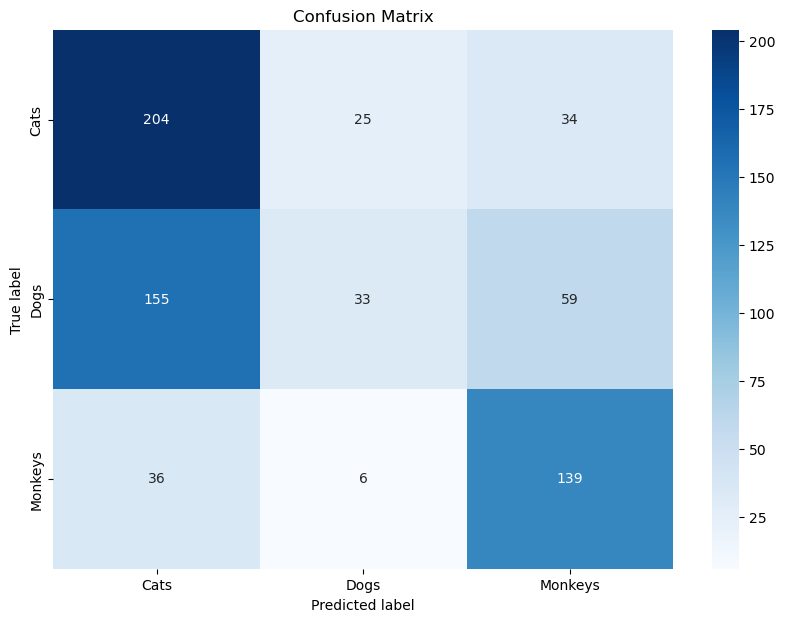

In [78]:
y_pred = best_model.predict(testX).argmax(axis=1)
cm = tf.math.confusion_matrix(testY.argmax(axis=1), y_pred)

# Optional: Define class names for better labeling
class_names = labels_str  # Replace with your actual class names

# Convert the matrix to a Pandas DataFrame for easier plotting with Seaborn
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)

# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    df_cm, annot=True, fmt="d", cmap="Blues"
)  # 'fmt="d"' ensures integer formatting
plt.title("Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

#### 7.3. Отобразим график обучения

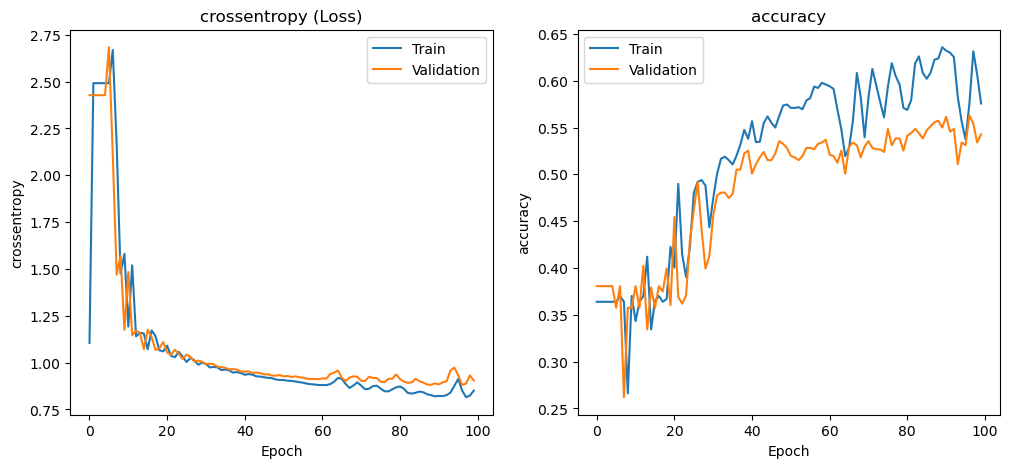

In [79]:
plt.figure(figsize=(12, 5))

# График MSE (loss)
plt.subplot(1, 2, 1)
plt.plot(H.history["loss"], label="Train")
plt.plot(H.history["val_loss"], label="Validation")
plt.title("crossentropy (Loss)")
plt.xlabel("Epoch")
plt.ylabel("crossentropy")
plt.legend()

# График accuracy
plt.subplot(1, 2, 2)
plt.plot(H.history["accuracy"], label="Train")
plt.plot(H.history["val_accuracy"], label="Validation")
plt.title("accuracy")
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.legend()

plt.show()

### 8. Сохранение модели и меток классов:

In [122]:
MODEL_PATH = "best_img.keras"
CLASSES_PATH = "class_names.json"
with open(CLASSES_PATH, "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

best_model.save(MODEL_PATH)

### 9. Проверка обученной модели пользовательскими данными:

#### 9.1. Импортируем необходимые библиотеки

In [81]:
import gradio as gr
import tensorflow as tf
from PIL import Image

#### 9.2. Реализуем функцию для предобработки входных данных в той же последовательности, что и при формировании обучающей выборки:

In [123]:
class_names = None
with open(CLASSES_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)
best_model = load_model(MODEL_PATH)

#### 9.3. Определим функцию для осуществления прогноза по загруженной модели:

In [150]:
def predict_image(img):
    if img is None:
        return {}
    processed_image = preprocess_image(img, img_width, img_height)
    probs = best_model.predict(np.array(processed_image).reshape(1, -1), verbose=0)[0]

    # Делаем mapping: индекс -> имя класса
    idx_to_class = {v: k for k, v in class_names.items()}

    top_idx = np.argsort(probs)[::-1]
    return {idx_to_class[i]: float(probs[i]) for i in top_idx if i in idx_to_class}

### 10. Визуализируем интерфейс и произведем классификацию:

In [152]:
with gr.Blocks(title="Image Classifier (Собаки, Кошки, Обезьяны)") as demo2:
    gr.Markdown("# Классификация изображения")

    with gr.Row():
        inp = gr.Image(type="numpy", label="Загрузить изображение")
        out = gr.Label(num_top_classes=5, label="Результат")

    btn = gr.Button("Классифицировать")
    btn.click(predict_image, inputs=inp, outputs=out)
try:
    demo2.launch(server_name="0.0.0.0", server_port=7001)
except OSError:
    gr.close_all()

* Running on local URL:  http://0.0.0.0:7001
* To create a public link, set `share=True` in `launch()`.
